In [2]:
import numpy as np
import pandas as pd
import os as os
import matplotlib.pyplot as plt
from PIL import Image

In [3]:
!pip install split-folders pillow ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.7 MB/s eta 0:00:00


In [4]:
!pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 72.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 140.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.18
    Uninstalling idna-3.18:
      Successfully uninstalled idna-3.18


In [6]:
from roboflow import Roboflow
from google.colab import userdata

roboflow_api_key = userdata.get('ROBOFLOW_API_KEY')
rf = Roboflow(api_key=roboflow_api_key)
project = rf.workspace("thaidd").project("coca-pepsi-juhuf")
version = project.version(5)
dataset = version.download("yolov11")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Coca-Pepsi-5 in yolov11:: 100%|██████████| 2570/2570 [00:00<00:00, 9910.35it/s]


In [ ]:
# Specify the path to the file
file_path = '/content/Coca-Pepsi-5/data.yaml'

# Check if the file exists
if os.path.exists(file_path):
  print(f"The file at {file_path} exists.")
else:
  print(f"The file at {file_path} does not exist.")

The file at /content/Coca-Pepsi-5/data.yaml exists.


In [ ]:
# Get the current working directory
cwd = os.getcwd()
print(f"Current working directory: {cwd}")

# List all files and directories in the current directory
files = os.listdir(cwd)
print(f"Files and directories in '{cwd}': {files}")

Current working directory: /content
Files and directories in '/content': ['.config', 'Coca-Pepsi-5', 'sample_data']


In [ ]:
dir_path = cwd + "/sample_data"
for files in os.listdir(dir_path):
  os.remove(dir_path + "/" + files)
os.rmdir(dir_path)

In [ ]:
from ultralytics import YOLO
model = YOLO("yolo11l.pt")
model.info()

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLO11l summary: 357 layers, 25,372,160 parameters, 0 gradients, 87.6 GFLOPs


(357, 25372160, 0, 87.6134912)

In [ ]:
from ultralytics import settings

# View all settings

settings.update({'datasets_dir': '/content/Coca-Pepsi-5'})

In [ ]:
# os.chdir("/content")
# Entrenar el modelo
model.train(
    data='/content/Coca-Pepsi-5/data.yaml',
    epochs=50,
    imgsz=640,
    batch=16,  # Ajusta según tu GPU
    name="entrenamiento_logos_pepsi_cocacola",
    project="proyecto_logos_team1"
)

Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Coca-Pepsi-5/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11l.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=entrenamiento_logos_pepsi_cocacola-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e5472959760>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [ ]:
# Listar archivos en el directorio
directory = "/content/runs/detect/proyecto_logos_team1/entrenamiento_logos_pepsi_cocacola-2"
if os.path.exists(directory):
    print("Archivos en el directorio:")
    print(os.listdir(directory))
else:
    print(f"El directorio {directory} no existe.")

Archivos en el directorio:
['weights', 'val_batch0_pred.jpg', 'BoxP_curve.png', 'val_batch0_labels.jpg', 'results.png', 'BoxPR_curve.png', 'BoxF1_curve.png', 'train_batch1.jpg', 'train_batch2801.jpg', 'train_batch2800.jpg', 'results.csv', 'val_batch1_labels.jpg', 'val_batch2_labels.jpg', 'BoxR_curve.png', 'confusion_matrix_normalized.png', 'train_batch0.jpg', 'val_batch2_pred.jpg', 'val_batch1_pred.jpg', 'train_batch2.jpg', 'confusion_matrix.png', 'train_batch2802.jpg', 'args.yaml', 'labels.jpg']


In [ ]:
# Crear DataFrame de métricas de entrenamiento
df_metrics = pd.read_csv("/content/runs/detect/proyecto_logos_team1/entrenamiento_logos_pepsi_cocacola-2/results.csv")


# Mostrar algunas métricas
print(df_metrics.head(5))

print(df_metrics.index.to_list())
print(df_metrics.columns.to_list())

df_metrics.describe()

   epoch      time  train/box_loss  train/cls_loss  train/dfl_loss  \
0      1   72.9245         1.55643         1.90721         1.96543   
1      2  129.9990         1.63649         1.66949         1.93249   
2      3  182.6310         1.69431         1.74018         1.98929   
3      4  235.3660         1.61577         1.72530         1.93883   
4      5  288.8640         1.58485         1.70138         1.88846   

   metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  \
0               0.00155            0.22027           0.00038   
1               0.02662            0.07888           0.00665   
2               0.10795            0.09518           0.03945   
3               0.18589            0.26886           0.17415   
4               0.17699            0.41111           0.13779   

   metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss    lr/pg0  \
0              0.00006       4.12140    6638.58000      47.10510  0.000548   
1              0.00172       4.32018  

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
count,50.00000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,48.000000,48.000000,48.000000,50.000000,50.000000,50.000000
mean,25.50000,1481.050390,1.156080,1.031410,1.552525,0.736550,0.769223,0.787767,0.389527,1.895409,140.002895,3.339382,0.000825,0.000825,0.000825
std,14.57738,852.449719,0.242452,0.361205,0.182333,0.239334,0.205779,0.265080,0.166384,0.610274,957.951210,6.569324,0.000456,0.000456,0.000456
min,1.00000,72.924500,0.759050,0.486870,1.314400,0.001550,0.078880,0.000380,0.000060,1.274480,0.644810,1.601300,0.000050,0.000050,0.000050
25%,13.25000,760.021500,1.014493,0.844348,1.416307,0.767130,0.773818,0.837450,0.316352,1.623165,0.807492,1.977495,0.000454,0.000454,0.000454
50%,25.50000,1474.720000,1.138775,0.989225,1.502150,0.833195,0.838810,0.903335,0.426765,1.748215,0.980570,2.130445,0.000825,0.000825,0.000825
75%,37.75000,2199.435000,1.314118,1.260935,1.651065,0.854877,0.880650,0.924327,0.515033,1.990405,1.271985,2.432345,0.001197,0.001197,0.001197
max,50.00000,2931.920000,1.694310,1.907210,1.989290,0.928400,0.929150,0.946280,0.601880,4.320180,6638.580000,47.105100,0.001593,0.001593,0.001593


['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


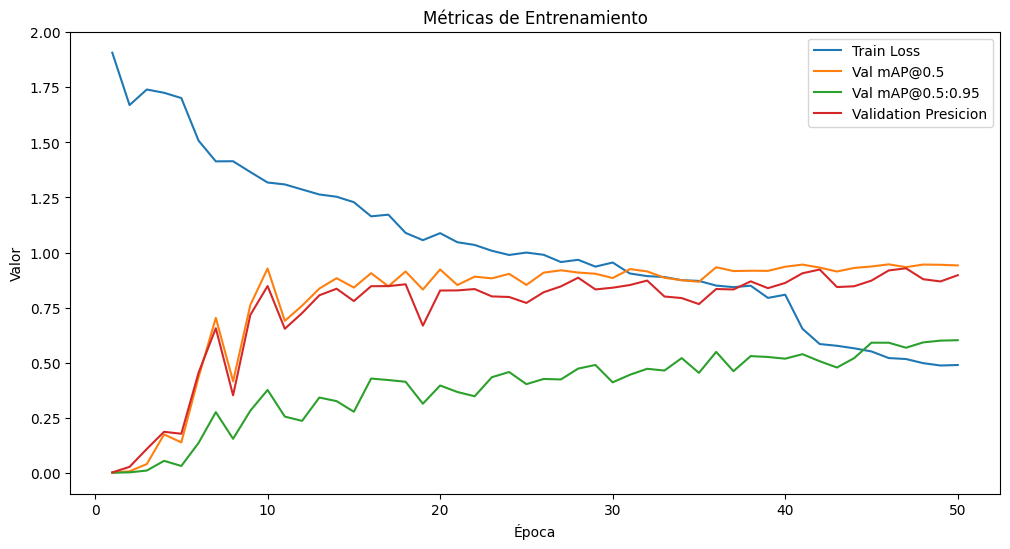

In [ ]:
print(df_metrics.columns.to_list())
# Graficar las métricas
plt.figure(figsize=(12, 6))
plt.plot(df_metrics[['epoch']], df_metrics[['train/cls_loss']], label='Train Loss')
plt.plot(df_metrics[['epoch']], df_metrics[['metrics/mAP50(B)']], label='Val mAP@0.5')
plt.plot(df_metrics[['epoch']], df_metrics[['metrics/mAP50-95(B)']], label='Val mAP@0.5:0.95')
plt.plot(df_metrics[['epoch']], df_metrics[['metrics/precision(B)']], label='Validation Presicion')
plt.xlabel('Época')
plt.ylabel('Valor')
plt.title('Métricas de Entrenamiento')
plt.legend()
plt.show()

In [ ]:
# Evaluar el modelo
results = model.val()

# Mostrar los resultados
print(results)

Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11l summary (fused): 191 layers, 25,280,854 parameters, 0 gradients, 86.6 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 978.5±309.9 MB/s, size: 24.5 KB)
val: Scanning /content/Coca-Pepsi-5/valid/labels.cache... 105 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 105/105 40.0Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 2, len(boxes) = 128. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.5it/s 4.5s
                   all        105        128      0.897      0.883      0.941      0.602
              CocaCola         50         65      0.882      0.862      0.945      0.554
                 Pepsi         59      

In [ ]:
# Cargar el modelo entrenado
# modelo_entrenado = YOLO("/content/yolov8n.pt")
modelo_entrenado = YOLO("/content/runs/detect/proyecto_logos_team1/entrenamiento_logos_pepsi_cocacola-2/weights/best.pt")

# Realizar inferencia en una imagen
resultados = modelo_entrenado.predict(source="/content/cocacola1.jpg", save=True)

# Acceder a los resultados
for resultado in resultados:
    print(f"Predicciones para la imagen: {resultado.path}")

    for caja, conf, clase in zip(resultado.boxes.xyxy, resultado.boxes.conf, resultado.boxes.cls):
        print(f"Bounding Box: {caja} - Confianza: {conf} - Clase: {clase}")


image 1/1 /content/cocacola1.jpg: 384x640 1 CocaCola, 97.7ms
Speed: 3.7ms preprocess, 97.7ms inference, 5.6ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /content/runs/detect/predict
Predicciones para la imagen: /content/cocacola1.jpg
Bounding Box: tensor([  7.9464,   0.0000, 248.0000, 148.0000], device='cuda:0') - Confianza: 0.8582208156585693 - Clase: 0.0


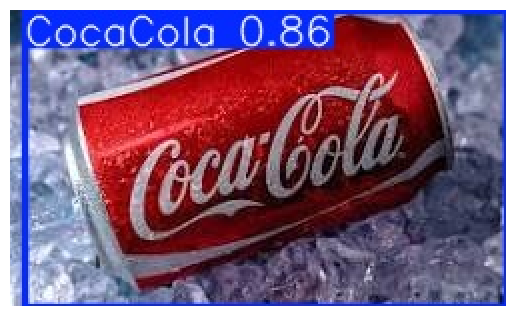

In [ ]:
# Cargar y mostrar la imagen con las predicciones
img = Image.open("/content/runs/detect/predict/cocacola1.jpg")
plt.imshow(img)
plt.axis('off')  # Ocultar los ejes
plt.show()

In [ ]:
# Realizar inferencia en una imagen
resultados = modelo_entrenado.predict(source="/content/cocacola3.jpg", save=True)

# Acceder a los resultados
for resultado in resultados:
    print(f"Predicciones para la imagen: {resultado.path}")

    for caja, conf, clase in zip(resultado.boxes.xyxy, resultado.boxes.conf, resultado.boxes.cls):
        print(f"Bounding Box: {caja} - Confianza: {conf} - Clase: {clase}")


image 1/1 /content/cocacola3.jpg: 448x640 1 CocaCola, 95.6ms
Speed: 4.3ms preprocess, 95.6ms inference, 1.9ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict
Predicciones para la imagen: /content/cocacola3.jpg
Bounding Box: tensor([  0.0000,   0.6637, 140.4878, 134.2598], device='cuda:0') - Confianza: 0.8557324409484863 - Clase: 0.0


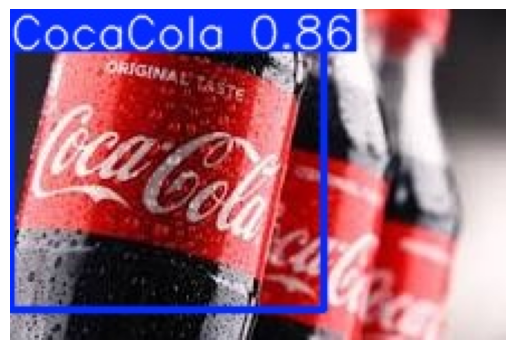

In [ ]:
# Cargar y mostrar la imagen con las predicciones
img = Image.open("/content/runs/detect/predict/cocacola3.jpg")
plt.imshow(img)
plt.axis('off')  # Ocultar los ejes
plt.show()

In [ ]:
# Realizar inferencia en una imagen
resultados = modelo_entrenado.predict(source="/content/pepsi_cocacola2.jpg", save=True)

# Acceder a los resultados
for resultado in resultados:
    print(f"Predicciones para la imagen: {resultado.path}")

    for caja, conf, clase in zip(resultado.boxes.xyxy, resultado.boxes.conf, resultado.boxes.cls):
        print(f"Bounding Box: {caja} - Confianza: {conf} - Clase: {clase}")


image 1/1 /content/pepsi_cocacola2.jpg: 640x640 2 CocaColas, 1 Pepsi, 48.1ms
Speed: 2.7ms preprocess, 48.1ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
Predicciones para la imagen: /content/pepsi_cocacola2.jpg
Bounding Box: tensor([ 85.9118,   1.0818, 142.4220,  89.2807], device='cuda:0') - Confianza: 0.8383497595787048 - Clase: 1.0
Bounding Box: tensor([ 5.5621,  1.1212, 67.9737, 93.4420], device='cuda:0') - Confianza: 0.4807071089744568 - Clase: 0.0
Bounding Box: tensor([ 94.8988,  83.2350, 143.1685, 147.8419], device='cuda:0') - Confianza: 0.3044551908969879 - Clase: 0.0


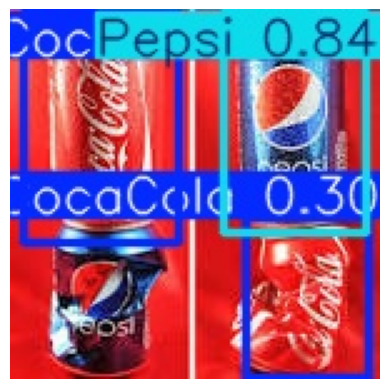

In [ ]:
# Cargar y mostrar la imagen con las predicciones
img = Image.open("/content/runs/detect/predict/pepsi_cocacola2.jpg")
plt.imshow(img)
plt.axis('off')  # Ocultar los ejes
plt.show()

In [ ]:
import shutil
from google.colab import files

# Especifica el nombre de la carpeta que deseas comprimir y descargar
folder_path = "/content/runs/detect/proyecto_logos_team1"  # Ruta de la carpeta en Colab
output_filename = "juanma_pepsi_cocacola_1250_v1.zip"   # Nombre del archivo zip de salida

# Comprimir la carpeta en un archivo ZIP
shutil.make_archive(output_filename.replace('.zip', ''), 'zip', folder_path)

# Descargar el archivo ZIP
files.download(output_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>